# Overlap Analysis
This notebook reproduces the overlap analysis reported in Section 5 and Table 2/Figure 3 of the paper:
> **Beyond Black-Box Labels: Interpretable Criteria for Diagnosing Subjective NLP Tasks**

It computes two separability measures:

**Criterion-level:**
- **Γ_{s,t}**: set of criteria engaged for each unit s
- **|Γ_{s,t}|**: count of simultaneously engaged criteria per unit
- **CondOv_t(q→q')**: directed conditional overlap between criteria pairs

**Category-level:**
- **g_{sk,t}**: binary indicator — is category c_k active for unit s?
- **m_{s,t}**: number of active non-target categories per unit
- **Overlap_cat|cov,t**: fraction of covered units activating ≥2 categories

**Reproduces:** Table 2 and Figure 3 of the paper.

## 1. Setup and load tensor

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────
TENSOR_DIR  = Path(r"/mnt/e/ACL paper Code/annotation-schema-diagnostic/data/tensors/run_2026-04-13_14-00_FULL_AGGREGATED")
# TENSOR_DIR  = Path("../data/tensors")
TENSOR_NPY  = TENSOR_DIR / "tensor_raw_4700.npy"

CRITERIA = [
    "q01_CostReduction",
    "q02_OperationalEfficiency",
    "q03_OrganizationalImpact",
    "q04_UserWellbeing",
    "q05_ReputationRecognition",
    "q06_PerceivedQuality",
    "q07_RegulatoryCompliance",
    "q08_RiskPrevention",
    "q09_MandatoryRequirement",
]

SHORT_NAMES = ["q1","q2","q3","q4","q5","q6","q7","q8","q9"]

# Category mapping (see Section 4.1)
# c1: Performance & Efficiency   → q01, q02, q03 (indices 0,1,2)
# c2: User Experience & Brand    → q04, q05, q06 (indices 3,4,5)
# c3: Obligation & Safety        → q07, q08, q09 (indices 6,7,8)
CATEGORY_MAP = {
    "c1_Performance": [0, 1, 2],
    "c2_UserExperience": [3, 4, 5],
    "c3_Obligation": [6, 7, 8],
}

A = 5
t = 1
N_CRITERIA = 9

# ── Load tensor ───────────────────────────────────────────────────
tensor = np.load(TENSOR_NPY)
tensor_main = tensor[:, :N_CRITERIA, 1:]  # exclude Gemini
valid_mask = np.all(tensor_main != -1, axis=(1,2))
tensor_main = tensor_main[valid_mask]
N_SENTENCES = tensor_main.shape[0]

# ── Vote counts and focus sets ────────────────────────────────────
vote_counts = tensor_main.sum(axis=2)      # shape: (N, 9)
focus_sets  = vote_counts >= t             # shape: (N, 9), boolean

print(f"Valid sentences : {N_SENTENCES}")
print(f"Tensor shape    : {tensor_main.shape}")

Valid sentences : 4698
Tensor shape    : (4698, 9, 5)


## 2. Criterion engagement: Γ_{s,t} and |Γ_{s,t}|

In [12]:
# ── Γ_{s,t}: number of criteria engaged per unit ──────────────────
gamma = focus_sets.sum(axis=1)  # shape: (N,), count of engaged criteria per unit

# Distribution of |Γ_{s,t}| over covered units (ms,t >= 1)
covered_mask = gamma >= 1
gamma_covered = gamma[covered_mask]
n_covered = covered_mask.sum()

print(f"Covered units (ms,t >= 1): {n_covered} ({n_covered/N_SENTENCES*100:.1f}%)")
print()

# Table 2A
print("Table 2A: Criterion engagement counts |Γ_{s,1}| over covered units")
print(f"{'Count':<10} {'# Units':<10} {'% of covered':<15}")
for k in [1, 2, 3]:
    n = (gamma_covered == k).sum()
    print(f"{k:<10} {n:<10} {n/n_covered*100:.1f}%")
n_4plus = (gamma_covered >= 4).sum()
print(f"{'>=4':<10} {n_4plus:<10} {n_4plus/n_covered*100:.1f}%")
print(f"\nMean |Γ_s,1| over covered units: {gamma_covered.mean():.2f}")

Covered units (ms,t >= 1): 1951 (41.5%)

Table 2A: Criterion engagement counts |Γ_{s,1}| over covered units
Count      # Units    % of covered   
1          690        35.4%
2          419        21.5%
3          325        16.7%
>=4        517        26.5%

Mean |Γ_s,1| over covered units: 2.56


## 3. Category-level overlap: g_{sk,t} and m_{s,t}

In [13]:
# ── g_{sk,t}: is category c_k active for unit s? ──────────────────
# c_k is active if ANY of its supporting criteria is engaged
g = np.zeros((N_SENTENCES, 3), dtype=int)  # 3 substantive categories
for k, (cat_name, indices) in enumerate(CATEGORY_MAP.items()):
    g[:, k] = focus_sets[:, indices].any(axis=1).astype(int)

# ── m_{s,t}: number of active non-target categories ───────────────
m = g.sum(axis=1)  # shape: (N,)

# ── Coverage and overlap ──────────────────────────────────────────
covered = m >= 1
overlap  = m >= 2

n_covered = covered.sum()
n_overlap  = overlap.sum()

overlap_rate = n_overlap / n_covered

print("Table 2B: Category metrics")
print(f"Covered (m_s,1 >= 1) : {n_covered} ({n_covered/N_SENTENCES*100:.1f}%)")
print(f"Overlap (m_s,1 >= 2) : {n_overlap} ({overlap_rate*100:.1f}% of covered)")
print(f"Mean |Γ_s,1|          : {gamma[covered].mean():.2f}")

Table 2B: Category metrics
Covered (m_s,1 >= 1) : 1951 (41.5%)
Overlap (m_s,1 >= 2) : 870 (44.6% of covered)
Mean |Γ_s,1|          : 2.56


## 4. Directed conditional overlap CondOv_t(q→q')

In [28]:
# ── Directed conditional overlap CondOv_t(q→q') ───────────────────
cond_ov = np.zeros((N_CRITERIA, N_CRITERIA))

for q in range(N_CRITERIA):
    for qp in range(N_CRITERIA):
        omega_q  = focus_sets[:, q]
        omega_qp = focus_sets[:, qp]
        intersection = (omega_q & omega_qp).sum()
        denom = omega_q.sum()
        if denom > 0:
            cond_ov[q, qp] = intersection / denom

print("Directed conditional overlap matrix computed.")
print(f"Shape: {cond_ov.shape}")

Directed conditional overlap matrix computed.
Shape: (9, 9)


## 5. Figure 3: Cross-category overlap heatmap

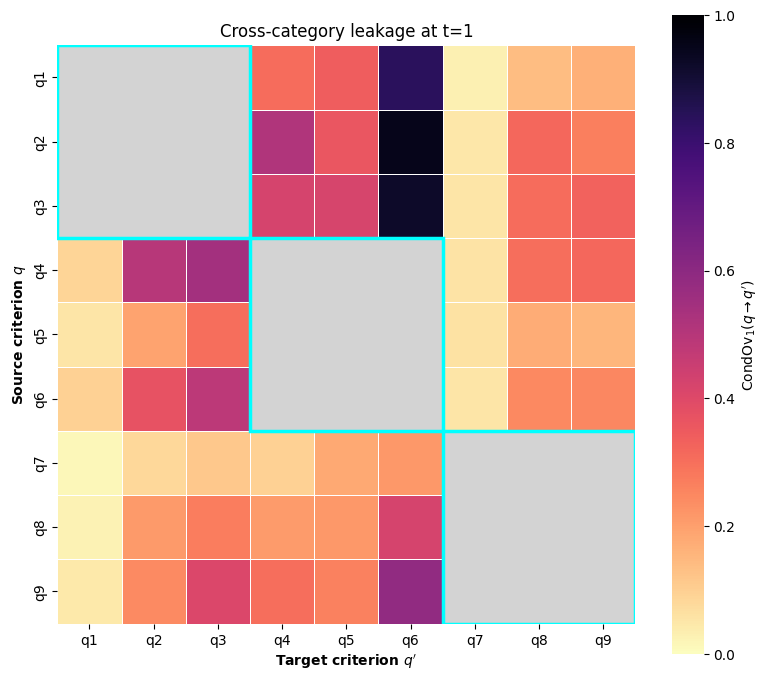

In [29]:
# Mask within-category blocks
mask = np.zeros((N_CRITERIA, N_CRITERIA), dtype=bool)
for indices in CATEGORY_MAP.values():
    for i in indices:
        for j in indices:
            mask[i, j] = True

cond_ov_masked = np.where(mask, np.nan, cond_ov)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cond_ov_masked,
    ax=ax,
    cmap="magma_r",
    vmin=0, vmax=1,
    xticklabels=SHORT_NAMES,
    yticklabels=SHORT_NAMES,
    annot=False,              # no numbers
    linewidths=0.5,
    linecolor='white',
    mask=None,
    cbar_kws={"label": r"CondOv$_1(q \rightarrow q')$"},
    square=True
)

# Gray for masked within-category blocks
for indices in CATEGORY_MAP.values():
    for i in indices:
        for j in indices:
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                fill=True, color='lightgray', zorder=2
            ))

# Cyan borders around within-category blocks
category_sizes = [3, 3, 3]
pos = 0
for size in category_sizes:
    ax.add_patch(plt.Rectangle(
        (pos, pos), size, size,
        fill=False, edgecolor='cyan', linewidth=2.5, zorder=3
    ))
    pos += size

ax.set_xlabel("Target criterion $q'$", fontweight='bold')
ax.set_ylabel("Source criterion $q$", fontweight='bold')
ax.set_title("Cross-category leakage at t=1")
plt.tight_layout()
plt.savefig("../results/figure3_overlap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

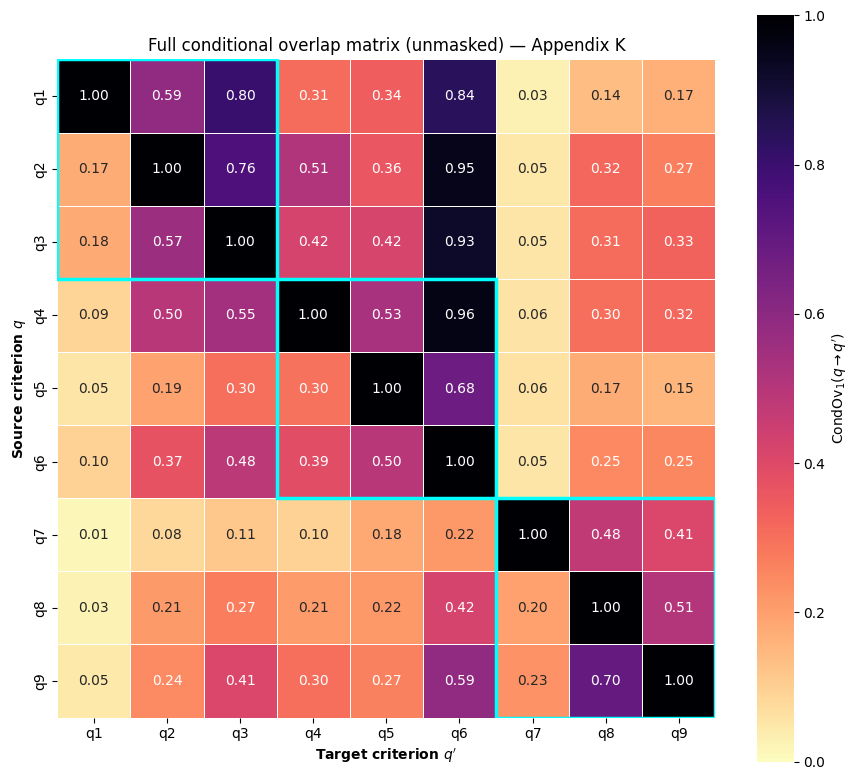

In [30]:
# ── Full unmasked matrix with values (Appendix K) ─────────────────
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    cond_ov,
    ax=ax,
    cmap="magma_r",
    vmin=0, vmax=1,
    xticklabels=SHORT_NAMES,
    yticklabels=SHORT_NAMES,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"label": r"CondOv$_1(q \rightarrow q')$"},
    square=True
)

# Cyan borders around within-category blocks
pos = 0
for size in [3, 3, 3]:
    ax.add_patch(plt.Rectangle(
        (pos, pos), size, size,
        fill=False, edgecolor='cyan', linewidth=2.5, zorder=3
    ))
    pos += size

ax.set_xlabel("Target criterion $q'$", fontweight='bold')
ax.set_ylabel("Source criterion $q$", fontweight='bold')
ax.set_title("Full conditional overlap matrix (unmasked) — Appendix K")
plt.tight_layout()
plt.savefig("../results/appendixK_full_overlap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()